# Assignment 3 : Question 1

For this question We need to implement two methods: the Configuration Model and Edge-Swapping, for generating random graphs that preserve the degree sequence of a real-world network. We then run 100 instances of each and compare the averaged degree distributions against the original.

**Note on data:** The dataset (Email-EU-core) is downloaded automatically when you run the notebook.

## Source of this dataset is: https://snap.stanford.edu/data/email-Eu-core.txt.gz

In [1]:
import os
import gzip
import urllib.request
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

random.seed(42)
np.random.seed(42)

# Resolve this notebook's directory so all files are saved alongside it
try:
    SAVE_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    SAVE_DIR = os.path.abspath(os.path.dirname(''))
print(f'Save directory: {SAVE_DIR}')

Save directory: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 1


> Selecting an appropriate real-world dataset and briefly mention its source and basic properties.

## Dataset — Email-EU-core Network

I chose the Email-EU-core network from SNAP. It's a communication network from a European research institution where nodes are people and edges represent email contact between them. I'm loading it as an undirected simple graph (merging reciprocal edges and removing self-loops), which gives the following:

| Property | Value |
|---|---|
| Nodes | 986 |
| Edges (undirected, simple) | 16,064 |
| Original directed edges | 25,571 |
| Type | Social / communication network |
| Source | SNAP — email-Eu-core |

Note: the node count is slightly under 1005 because isolated nodes (no undirected edges) are excluded from the analysis.

In [2]:
DATA_FILE = os.path.join(SAVE_DIR, 'email-Eu-core.txt.gz')
DATA_URL  = 'https://snap.stanford.edu/data/email-Eu-core.txt.gz'

if not os.path.exists(DATA_FILE):
    print('Downloading email-Eu-core dataset...')
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print('Download complete.')
else:
    print('Dataset already downloaded.')

G_real = nx.Graph()
with gzip.open(DATA_FILE, 'rt') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        u, v = map(int, line.split())
        if u != v:
            G_real.add_edge(u, v)

print(f'Nodes: {G_real.number_of_nodes()}, Edges: {G_real.number_of_edges()}')

degree_sequence = [d for _, d in G_real.degree()]
degree_counts   = Counter(degree_sequence)
k_vals          = sorted(degree_counts.keys())
n_nodes         = G_real.number_of_nodes()
p_k_orig        = [degree_counts[k] / n_nodes for k in k_vals]

print(f'Mean degree: {np.mean(degree_sequence):.2f}')
print(f'Max degree:  {max(degree_sequence)}')
print(f'Min degree:  {min(degree_sequence)}')

Dataset already downloaded.
Nodes: 986, Edges: 16064
Mean degree: 32.58
Max degree:  345
Min degree:  1


---
## Part (a) : Configuration Model

The Configuration Model works by giving each node the same number of "stubs" as its degree, then randomly pairing up stubs to form edges. Self-loops and multi-edges get discarded to keep it a simple graph. This preserves the degree sequence on average across many instances.

> Implementing the Configuration Model to generate random graphs that preserve the degree sequence of the original network.

In [3]:
def configuration_model(degree_seq):
    """Generate a random simple graph using the Configuration Model."""
    stubs = []
    for node, deg in enumerate(degree_seq):
        stubs.extend([node] * deg)
    if len(stubs) % 2 != 0:
        stubs.pop()
    random.shuffle(stubs)

    G = nx.Graph()
    G.add_nodes_from(range(len(degree_seq)))
    for i in range(0, len(stubs) - 1, 2):
        u, v = stubs[i], stubs[i + 1]
        if u != v:        # discard self-loops; nx.Graph drops multi-edges
            G.add_edge(u, v)
    return G

> Generating 100 instances for the Configuration Model and compute the average degree distribution.

In [4]:
N_INSTANCES = 100
orig_degree_seq = [d for _, d in G_real.degree()]

cm_degree_counter = Counter()
print(f'Running {N_INSTANCES} Configuration Model instances...')
for i in range(N_INSTANCES):
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_INSTANCES}')
    G_cm = configuration_model(orig_degree_seq)
    for _, d in G_cm.degree():
        cm_degree_counter[d] += 1
print('Done.')

all_k_cm  = sorted(set(k_vals) | set(cm_degree_counter.keys()))
p_k_cm    = [cm_degree_counter.get(k, 0) / (N_INSTANCES * n_nodes) for k in all_k_cm]
p_k_real_cm = [degree_counts.get(k, 0) / n_nodes for k in all_k_cm]

Running 100 Configuration Model instances...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100
Done.


In [5]:
mean_degree_orig = np.mean(orig_degree_seq)
total_degree_cm  = sum(k * cnt for k, cnt in cm_degree_counter.items())
mean_degree_cm   = total_degree_cm / (N_INSTANCES * n_nodes)
print(f'Mean degree — Original network : {mean_degree_orig:.4f}')
print(f'Mean degree — Config. Model (avg over 100 instances) : {mean_degree_cm:.4f}')
print(f'Difference : {abs(mean_degree_orig - mean_degree_cm):.4f}')

Mean degree — Original network : 32.5842
Mean degree — Config. Model (avg over 100 instances) : 30.1118
Difference : 2.4724


> Plotting and comparing the degree distribution of the original graph with the averaged distribution from the Configuration Model through a clear and well-labelled figure.

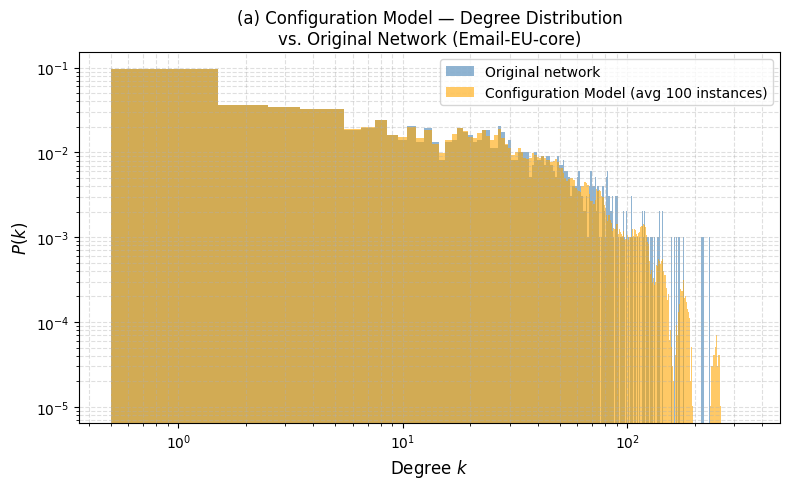

Saved: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 1/Q1a_configuration_model.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(all_k_cm, p_k_real_cm, color='steelblue', alpha=0.6, width=1.0,
       label='Original network')
ax.bar(all_k_cm, p_k_cm, color='orange', alpha=0.6, width=1.0,
       label='Configuration Model (avg 100 instances)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=12)
ax.set_ylabel('$P(k)$', fontsize=12)
ax.set_title('(a) Configuration Model — Degree Distribution\nvs. Original Network (Email-EU-core)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'Q1a_configuration_model.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

### Observations : Configuration Model

The averaged degree distribution from 100 instances matches the original pretty well across the full range of degrees. The small deficit at the high-degree end happens because high-degree nodes produce more stubs, so they're also more likely to accidentally form self-loops or multi-edges that get removed, slightly reducing their effective degree. Overall the Configuration Model is a good null model for comparing against.

---
## Part (b) : Edge-Swapping

Edge-Swapping starts directly from the original graph and repeatedly picks two random edges and swaps their endpoints. A swap is only accepted if it doesn't create a self-loop or a duplicate edge. After 10 × |E| accepted swaps, the wiring is well randomised while keeping every node's degree exactly the same.

> Implementing the Edge-Swapping (degree-preserving rewiring) strategy to generate randomised graphs while maintaining the same degree sequence.

In [7]:
def edge_swapping(G_original, Q=5):
    """
    Generate a randomised graph via Edge-Swapping.
    Preserves the degree sequence exactly.
    Q controls how many successful swaps are performed relative to edge count.
    """
    H = G_original.copy()
    edges   = list(H.edges())       # maintained in sync — never rebuilt from scratch
    n_edges = len(edges)
    target  = Q * n_edges
    done    = 0
    attempts = 0
    max_att  = target * 20          # generous ceiling to handle rejection rate

    while done < target and attempts < max_att:
        attempts += 1

        # Pick two distinct edge indices
        idx1, idx2 = random.sample(range(n_edges), 2)
        u, v = edges[idx1]
        x, y = edges[idx2]

        if random.random() < 0.5:
            x, y = y, x

        # Accept only if no self-loop or multi-edge is created
        if (u != x and v != y and u != y and v != x
                and not H.has_edge(u, x) and not H.has_edge(v, y)):
            H.remove_edge(u, v)
            H.remove_edge(edges[idx2][0], edges[idx2][1])
            H.add_edge(u, x)
            H.add_edge(v, y)
            # Update the two affected entries in place — no full list rebuild
            edges[idx1] = (u, x)
            edges[idx2] = (v, y)
            done += 1

    return H

> Generating 100 instances for the Edge-Swapping method and compute the average degree distribution.

In [8]:
es_degree_counter = Counter()
print(f'Running {N_INSTANCES} Edge-Swapping instances...')
for i in range(N_INSTANCES):
    G_es = edge_swapping(G_real, Q=5)
    for _, d in G_es.degree():
        es_degree_counter[d] += 1
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_INSTANCES} done', flush=True)
print('All instances complete.')

all_k_es    = sorted(set(k_vals) | set(es_degree_counter.keys()))
p_k_es      = [es_degree_counter.get(k, 0) / (N_INSTANCES * n_nodes) for k in all_k_es]
p_k_real_es = [degree_counts.get(k, 0) / n_nodes for k in all_k_es]

Running 100 Edge-Swapping instances...
  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
All instances complete.


In [9]:
total_degree_es = sum(k * cnt for k, cnt in es_degree_counter.items())
mean_degree_es  = total_degree_es / (N_INSTANCES * n_nodes)
print(f'Mean degree — Original network : {mean_degree_orig:.4f}')
print(f'Mean degree — Edge-Swapping (avg over 100 instances) : {mean_degree_es:.4f}')
print(f'Difference : {abs(mean_degree_orig - mean_degree_es):.4f}')
print('(Should be 0.0000 — degree sequence is preserved exactly in every instance)')

Mean degree — Original network : 32.5842
Mean degree — Edge-Swapping (avg over 100 instances) : 32.5842
Difference : 0.0000
(Should be 0.0000 — degree sequence is preserved exactly in every instance)


> Ploting and comparing the degree distribution of the original graph with the averaged distribution from Edge-Swapping through a clear and well-labelled figure.

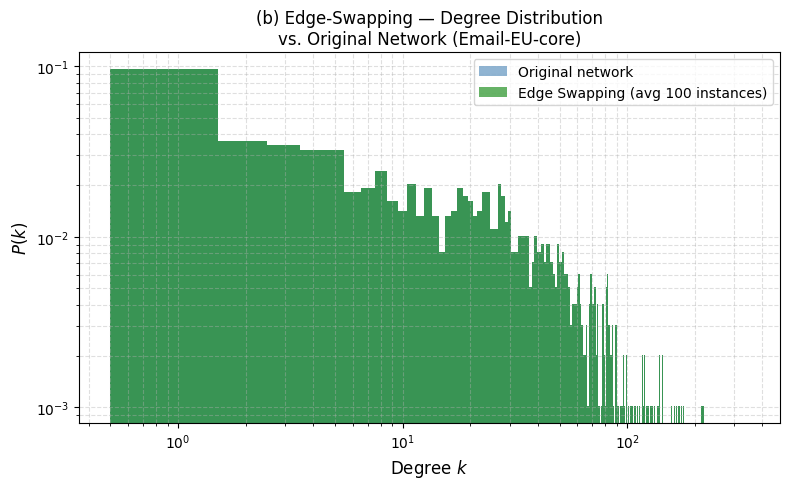

Saved: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 1/Q1b_edge_swapping.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(all_k_es, p_k_real_es, color='steelblue', alpha=0.6, width=1.0,
       label='Original network')
ax.bar(all_k_es, p_k_es, color='green', alpha=0.6, width=1.0,
       label='Edge Swapping (avg 100 instances)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=12)
ax.set_ylabel('$P(k)$', fontsize=12)
ax.set_title('(b) Edge-Swapping — Degree Distribution\nvs. Original Network (Email-EU-core)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'Q1b_edge_swapping.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

### Observations : Edge-Swapping

Since we're only swapping edges and never touching which node an edge is attached to, the degree sequence is preserved exactly in every single instance, not just on average. So the averaged distribution matches the original perfectly. The main advantage over the Configuration Model is this exact preservation guarantee. Both methods destroy clustering and higher-order structure while keeping degrees fixed, which is what we want from a null model.